### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

# 

# Assignment activity 1

### Plan your approach

In [ ]:
# To plan budgets and expand infrastructure effectively
the NHS must understand utilisation trends across its network as population demand grows. 
Some stakeholders feel that infrastructure and investment is sufficient whilst others think it is. 
Missing appointments costs the NHS significantly – why this happens needs to be understood rather than just punishing the poorest members in society.
Reducing / eliminating missed appointments would be hugely beneficial for the NHS #

The data I need to answer these questions is – 
Appointment ID
Appointment date
Location ID / location name
Service setting (e.g. GP, hospital, outpatient)
Context type (e.g. face-to-face, virtual)
National category
Appointment status 
Patient count 

clean, view explore and analyse actual_duration.csv,appointments_regional.csv and national_categories.xlsx


# 

# Assignment activity 2

### Prepare your workstation

In [4]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv("actual_duration.csv")

# View the DataFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439


In [6]:
# Determine whether there are missing values.
ad.isnull().sum()

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

In [7]:
# Determine the metadata of the data set.
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [8]:
# Determine the descriptive statistics of the data set.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [9]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv("appointments_regional.csv")

# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


In [10]:
# Determine whether there are missing values.
ar.isnull().sum()

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [11]:
# Determine the metadata of the data set.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [12]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [13]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel("national_categories.xlsx")

# View the DataFrame.
nc

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [14]:
# Determine whether there are missing values.
nc.isnull().sum()

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [15]:
# Determine the metadata of the data set.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [16]:
# Determine the descriptive statistics of the data set.
nc.describe()

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


### Explore the data set

**Question 1:** How many locations are there in the data set?

In [17]:
# Determine the number of locations.
ad.columns
ar.columns
nc.columns

Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')

**Question 2:** What are the five locations with the highest number of appointments?



In [18]:
# Determine the top five locations based on record count.

# Sum appointments by location
location_totals = ad.groupby(['sub_icb_location_name'])['count_of_appointments'].sum()

# Sort and get top 5
top_5_locations = location_totals.sort_values(ascending=False).head(5)

print("Top 5 locations by total number of appointments:")
print(top_5_locations)

Top 5 locations by total number of appointments:
sub_icb_location_name
NHS North West London ICB - W2U3Z              6976986
NHS North East London ICB - A3A8R              5341883
NHS Kent and Medway ICB - 91Q                  5209641
NHS Hampshire and Isle Of Wight ICB - D9Y0V    4712737
NHS South East London ICB - 72Q                4360079
Name: count_of_appointments, dtype: int64


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [19]:
# Determine the number of service settings.
# Determine the number of hcp type
num_service_settings = ar['hcp_type'].nunique()
print("Number of service settings:", num_service_settings)

# Determine the number of appointment date
num_service_settings = ad['appointment_date'].nunique()
print("Number of service settings:", num_service_settings)

# Determine the number of appointment status
num_service_settings = ar['appointment_status'].nunique()
print("Number of service settings:", num_service_settings)

# Determine the number of actual duration
num_service_settings = ad['actual_duration'].nunique()
print("Number of service settings:", num_service_settings)

# Determine the number of time between book and appointment
num_service_settings = ar['time_between_book_and_appointment'].nunique()
print("Number of service settings:", num_service_settings)

# Determine the number of count of appointments
num_service_settings = ar['count_of_appointments'].nunique()
print("Number of service settings:", num_service_settings)

#Determine what the service settings are
#Determine what the service settings are for hcp type
ar['hcp_type'].unique()

#Determine what the service settings are for appointment date
ad['appointment_date'].unique()

#Determine what the service settings are for appointment status
ar['appointment_status'].unique()

#Determine what the service settings are for actual duration 
ad['actual_duration'].unique()

#Determine what the service settings are for time between book and appointment
ar['time_between_book_and_appointment'].unique()

#Determine what the service settings are for count of appointment
ar['count_of_appointments'].unique()


Number of service settings: 3
Number of service settings: 212
Number of service settings: 3
Number of service settings: 7
Number of service settings: 8
Number of service settings: 22807


array([ 8107,  6791, 20686, ..., 21570, 10526, 20412])

In [20]:
# Determine the number of context types.
# Determine the number of appointment months
num_context_types = ar['appointment_month'].nunique()
print("Number of context types:", num_context_types)


# Determine the number of appointment modes
num_context_types = ar['appointment_mode'].nunique()
print("Number of context types:", num_context_types)


#Determine what the context types are for location code 
ar['appointment_month'].unique()

#Determine what the context types are for location ons code 
ar['appointment_mode'].unique()


Number of context types: 30
Number of context types: 5


array(['Face-to-Face', 'Home Visit', 'Telephone', 'Unknown',
       'Video/Online'], dtype=object)

In [21]:
# Determine the number of national categories.

# Determine the number of location codes
num_national_categories = ad['sub_icb_location_code'].nunique()
print("Number of national categories:", num_national_categories)

# Determine the number of location ons codes
num_national_categories = ad['sub_icb_location_ons_code'].nunique()
print("Number of national categories:", num_national_categories)

# Determine the number of location names
num_national_categories = ad['sub_icb_location_name'].nunique()
print("Number of national categories:", num_national_categories)

# Determine the number of region ons code 
num_national_categories = ad['region_ons_code'].nunique()
print("Number of national categories:", num_national_categories)

#Determine what the service settings are for location code 
ad['sub_icb_location_code'].unique()

#Determine what the service settings are for location ons code 
ad['sub_icb_location_ons_code'].unique()

#Determine what the service settings are for location names 
ad['sub_icb_location_name'].unique()

#Determine what the service settings are for region ons code 
ad['region_ons_code'].unique()


Number of national categories: 106
Number of national categories: 106
Number of national categories: 106
Number of national categories: 7


array(['E40000012', 'E40000010', 'E40000011', 'E40000007', 'E40000005',
       'E40000006', 'E40000003'], dtype=object)

In [22]:
# Determine the number of appointment statuses.
num_appointment_statuses = ar['appointment_status'].nunique()
print("appointment_status:", num_appointment_statuses)

#Determine what the service settings are for location code 
ar['appointment_status'].unique()

appointment_status: 3


array(['Attended', 'DNA', 'Unknown'], dtype=object)

# 

# Assignment activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [23]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad['appointment_date'].head()

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object

In [24]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.

print(nc['appointment_date'].head())

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]


In [25]:
# Change the date format of ad['appointment_date'].
ad["appointment_date"] = pd.to_datetime(ad["appointment_date"])

# View the DateFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,11-15 Minutes,1439


In [26]:
# Change the date format of ar['appointment_date'].
ar["appointment_month"] = pd.to_datetime(ar["appointment_month"])

# View the DateFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06-01,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06-01,Unknown,Unknown,Unknown,More than 28 Days,17


In [27]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.

# Minimum and maximum dates
first_date = ad['appointment_date'].min()
last_date = ad['appointment_date'].max()

print("First appointment date:", first_date)
print("Last appointment date:", last_date)

First appointment date: 2021-12-01 00:00:00
Last appointment date: 2022-06-30 00:00:00


In [30]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
first_date = nc['appointment_date'].min()
last_date = nc['appointment_date'].max()

print("First appointment date:", first_date)
print("Last appointment date:", last_date)

First appointment date: 2021-08-01 00:00:00
Last appointment date: 2022-06-30 00:00:00


**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [33]:
# For each of these service settings, determine the number of records available for the period and the location. 
ar["appointment_month"] = pd.to_datetime(ar["appointment_month"])
filtered = ar[
    (ar["icb_ons_code"] == "QKK") &
    (ar["appointment_month"] >= "2022-01-01") &
    (ar["appointment_month"] <= "2022-06-01")
]
# View the output.
print(filtered)

Empty DataFrame
Columns: [icb_ons_code, appointment_month, appointment_status, hcp_type, appointment_mode, time_between_book_and_appointment, count_of_appointments]
Index: []


**Question 3:** Which month had the highest number of appointments?

In [34]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.
ar.groupby("appointment_month")["count_of_appointments"] \
  .sum() \
  .sort_values()

appointment_month
2020-04-01    16007881
2020-05-01    16417212
2020-08-01    20150520
2020-06-01    20690805
2021-02-01    22399569
2020-07-01    22491437
2021-01-01    22492069
2021-05-01    23508395
2020-12-01    23535936
2021-08-01    23852171
2021-04-01    23879932
2022-04-01    23913060
2020-03-01    24053468
2020-02-01    24104621
2020-11-01    25061602
2021-12-01    25140776
2022-02-01    25355260
2022-01-01    25635474
2021-07-01    25739219
2022-06-01    25828078
2020-09-01    26714255
2021-06-01    26784182
2020-01-01    27199296
2021-03-01    27225424
2022-05-01    27495508
2020-10-01    28301932
2021-09-01    28522501
2022-03-01    29595038
2021-10-01    30303834
2021-11-01    30405070
Name: count_of_appointments, dtype: int64

**Question 4:** What was the total number of records per month?

In [35]:
# Total number of records per month.
ar.groupby("appointment_month").size()
ad.groupby("appointment_date").size()
nc.groupby("appointment_month").size()

appointment_month
2021-08    69999
2021-09    74922
2021-10    74078
2021-11    77652
2021-12    72651
2022-01    71896
2022-02    71769
2022-03    82822
2022-04    70012
2022-05    77425
2022-06    74168
dtype: int64

# 

# Assignment activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [36]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

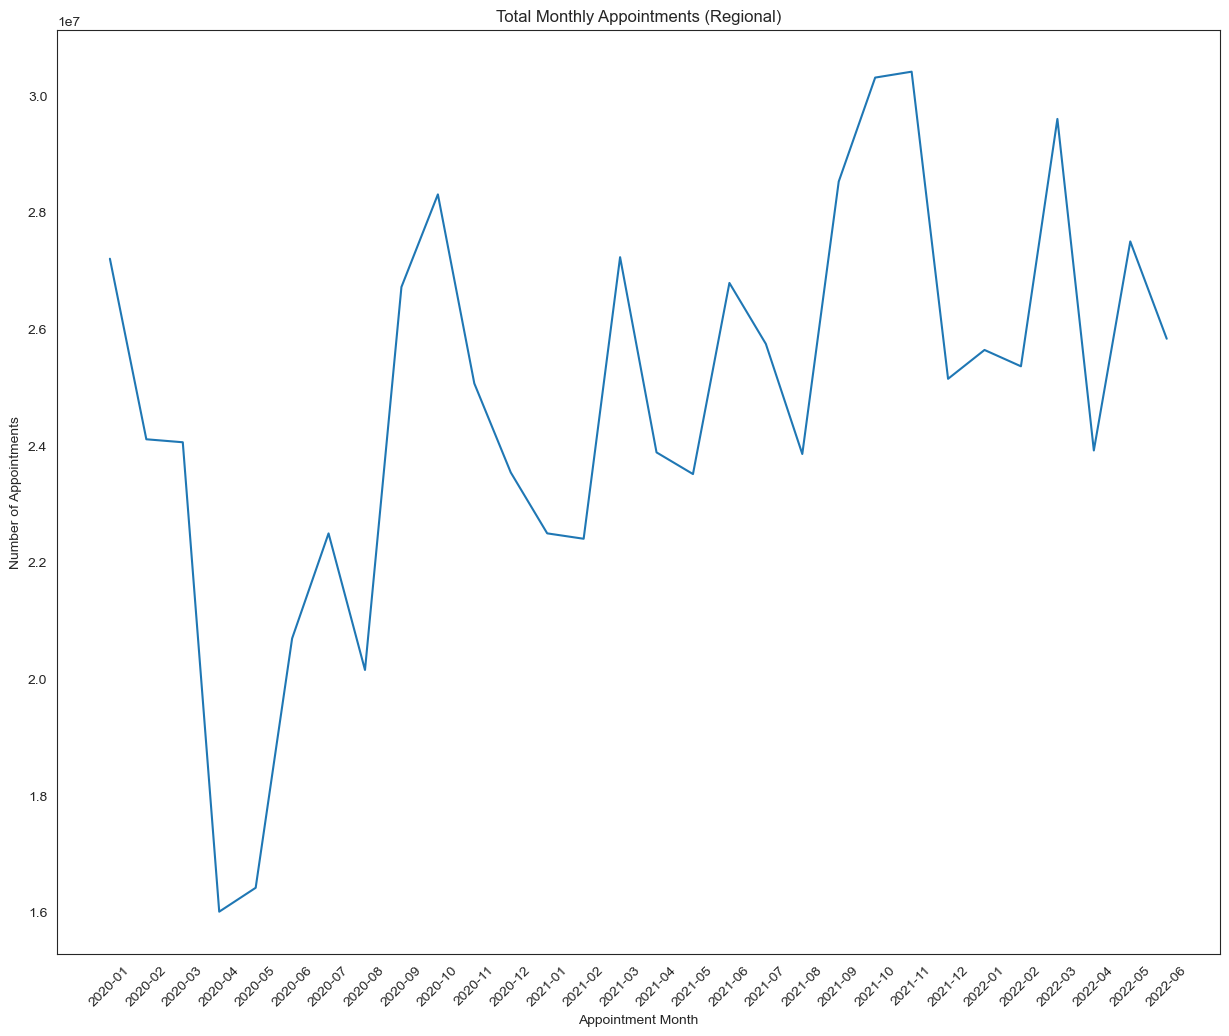

In [7]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set white style BEFORE plotting
sns.set_style("white")

# Load the regional appointments dataset
regional = pd.read_csv("appointments_regional.csv")

# View the first few rows to confirm successful loading
regional.head()

# Change the data type of appointment_month to string 
regional["appointment_month"] = regional["appointment_month"].astype(str)

# Aggregate total number of appointments per month
monthly_totals = (
    regional
    .groupby("appointment_month")["count_of_appointments"]
    .sum()
    .reset_index()
)

# View the aggregated output
monthly_totals.head()

# Create a line plot to visualise total monthly appointments
plt.figure(figsize=(15, 12))

sns.lineplot(
    data=monthly_totals,
    x="appointment_month",
    y="count_of_appointments",
    errorbar=None
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and axis labels
plt.title("Total Monthly Appointments (Regional)")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

# Save plot

plt.savefig("total_monthly_appointments_regional.pdf", bbox_inches="tight")

# Display the plot
plt.show()

In [11]:
# Aggregate on monthly level and determine the sum of records per month.

monthly_totals = (
    nc
    .groupby("appointment_month")["count_of_appointments"]
    .sum()
    .reset_index()
)

monthly_totals.head()
# View output
monthly_totals.head()

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776


**Service settings:**

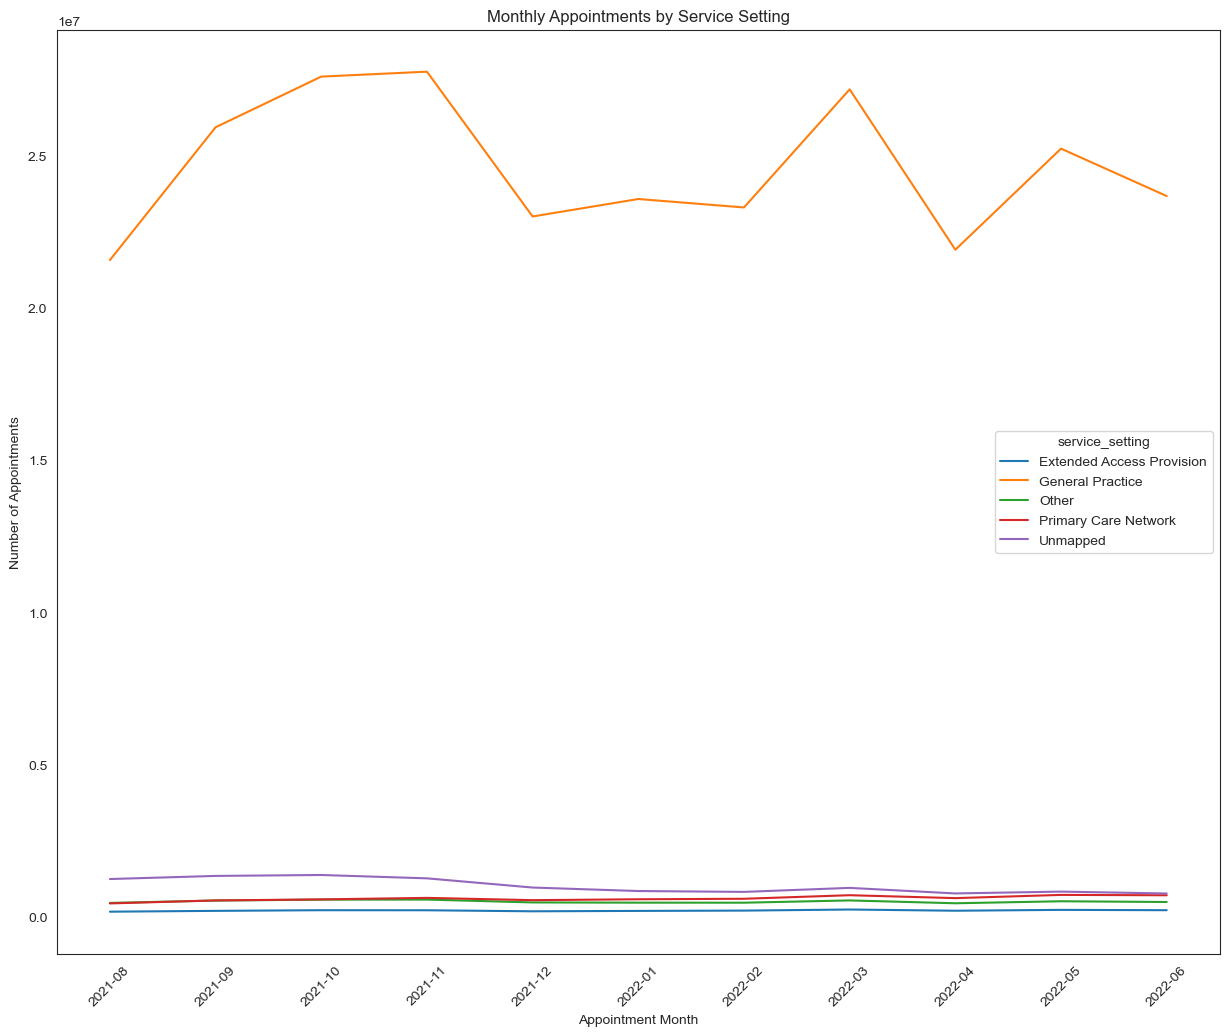

In [13]:
# Plot the appointments monthly by service settings
# Create a lineplot.
plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_month",
    y="count_of_appointments",
    hue="service_setting",
    data=nc_ss,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Monthly Appointments by Service Setting")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.savefig("monthly_service_setting.pdf", bbox_inches="tight") 

#show lineplot
plt.show()

**Context types:**

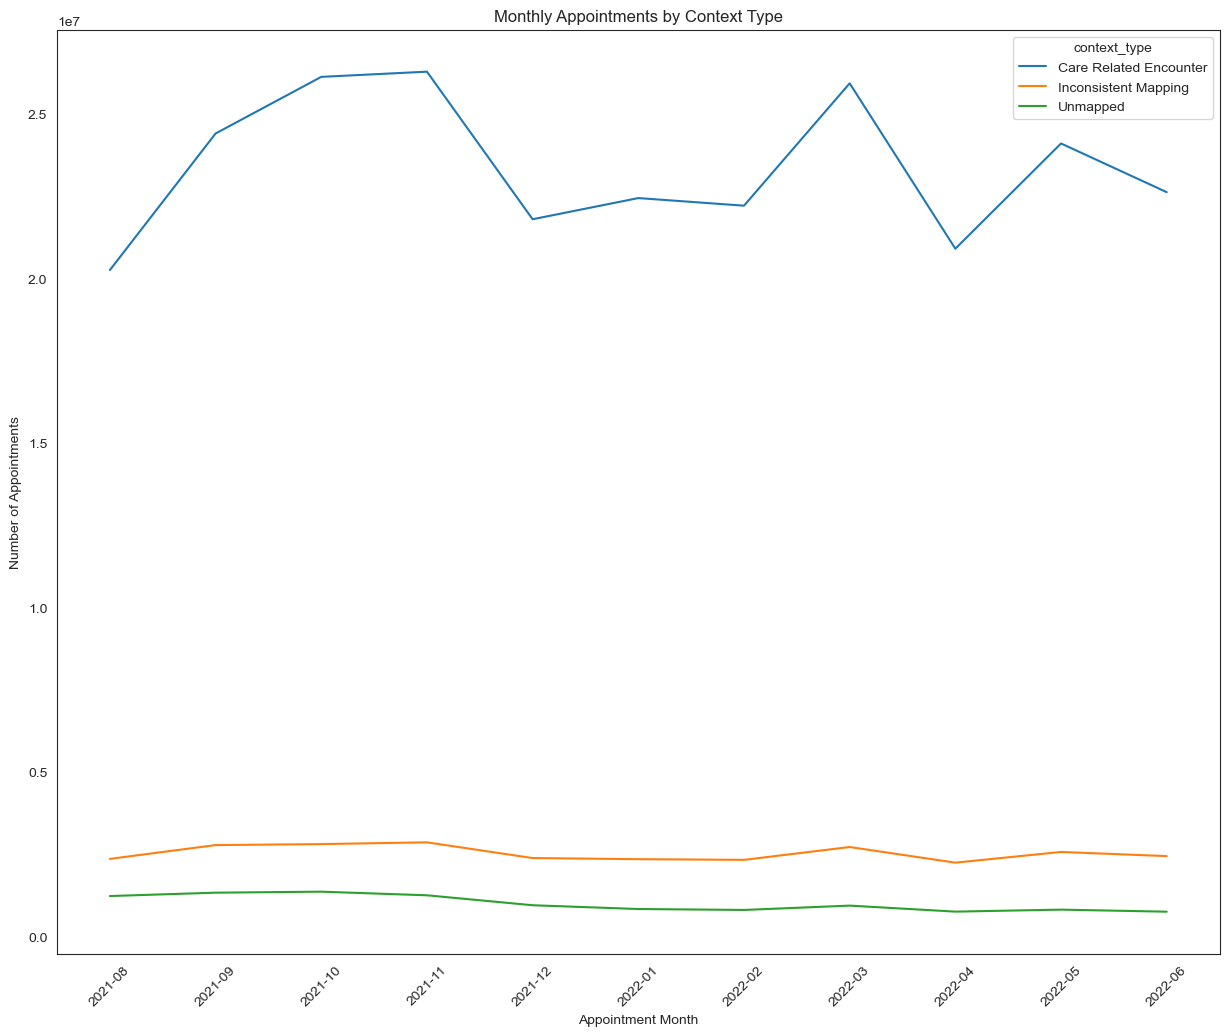

In [14]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_month",
    y="count_of_appointments",
    hue="context_type",
    data=nc_ct,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Monthly Appointments by Context Type")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.savefig("monthly_context_type.pdf", bbox_inches="tight") 
#show lineplot
plt.show()

**National categories:**

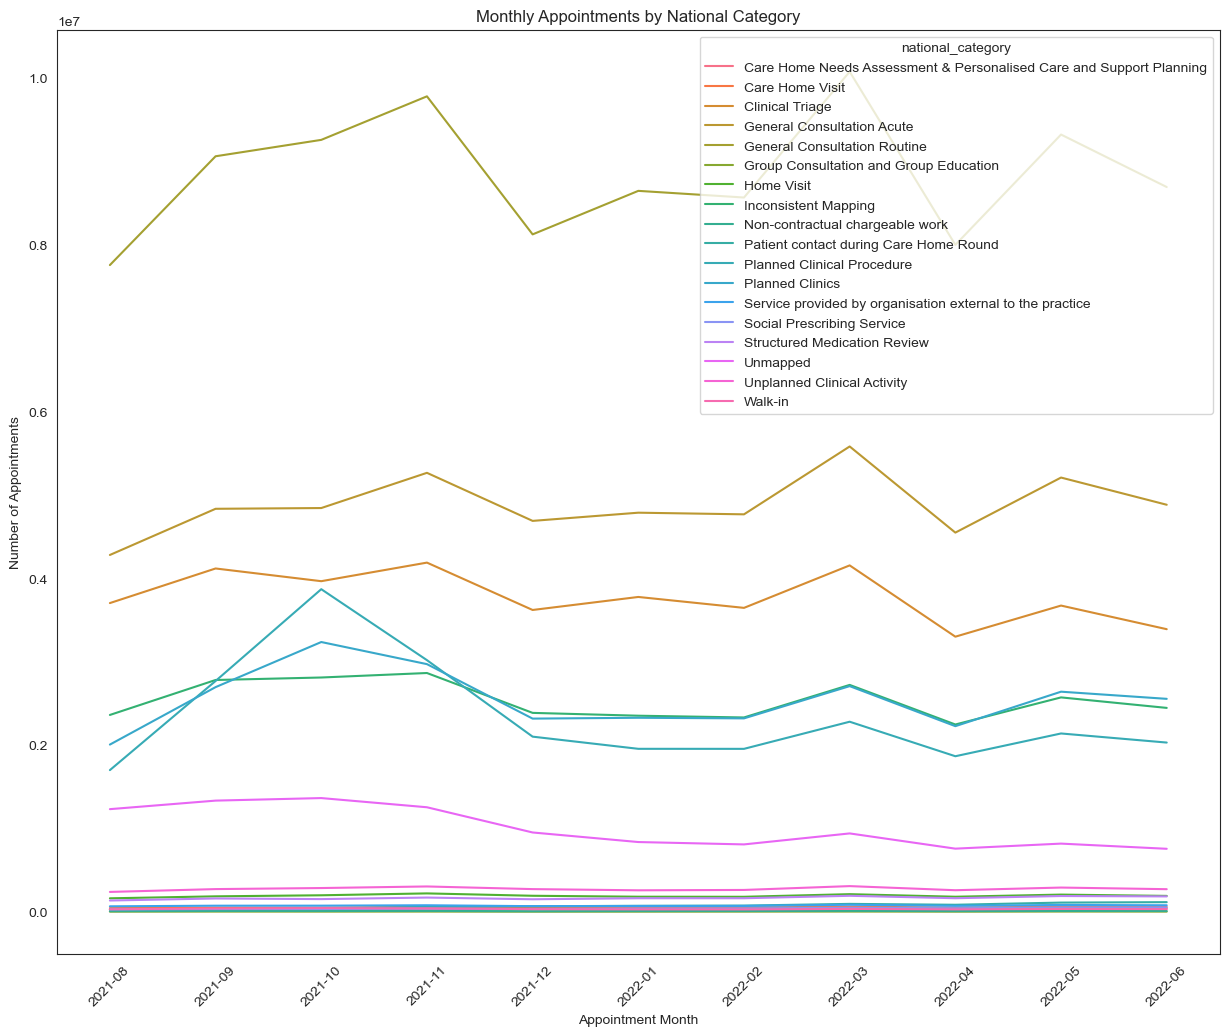

In [15]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.

plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_month",
    y="count_of_appointments",
    hue="national_category",
    data=nc_nc,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Monthly Appointments by National Category")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.savefig("monthly_national_category.pdf", bbox_inches="tight") 
#show lineplot
plt.show()


### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [17]:
# Create a separate data set that can be used in future weeks
# Load dataset (if not already loaded)
import pandas as pd
nc = pd.read_excel("national_categories.xlsx")

# Ensure correct formats
nc["appointment_date"] = pd.to_datetime(nc["appointment_date"])
nc["appointment_month"] = nc["appointment_month"].astype(str)

# Create nc_ss_day
nc_ss_day = (
    nc
    .groupby(["appointment_date", "appointment_month", "service_setting"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# View output
nc_ss_day.head()


# Create a separate data set that can be used in future weeks
summer_2021 = nc_ss_day[
    nc_ss_day["appointment_month"].isin(["2021-06", "2021-07", "2021-08"])
]

# View output
summer_2021.head()


,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08,Extended Access Provision,438
1,2021-08-01,2021-08,General Practice,3411
2,2021-08-01,2021-08,Other,401
3,2021-08-01,2021-08,Primary Care Network,323
4,2021-08-01,2021-08,Unmapped,1054


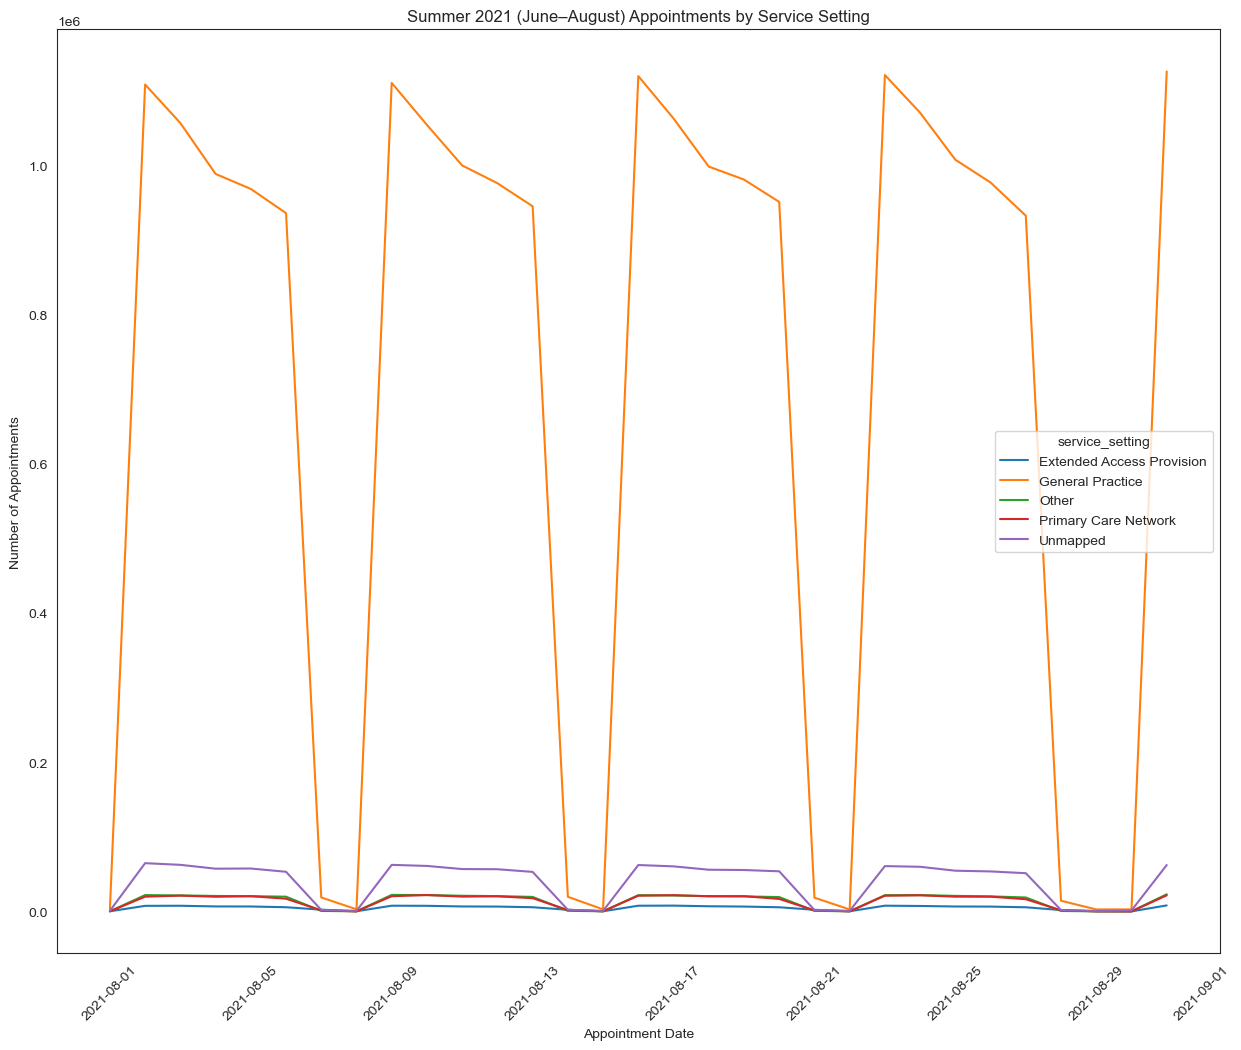

In [18]:
# Look at June to August 2021 in more detail to allow a closer look.
# Create a lineplot.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_date",
    y="count_of_appointments",
    hue="service_setting",
    data=summer_2021,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Summer 2021 (June–August) Appointments by Service Setting")
plt.xlabel("Appointment Date")
plt.ylabel("Number of Appointments")

plt.show()

**Autumn (September to November 2021):**

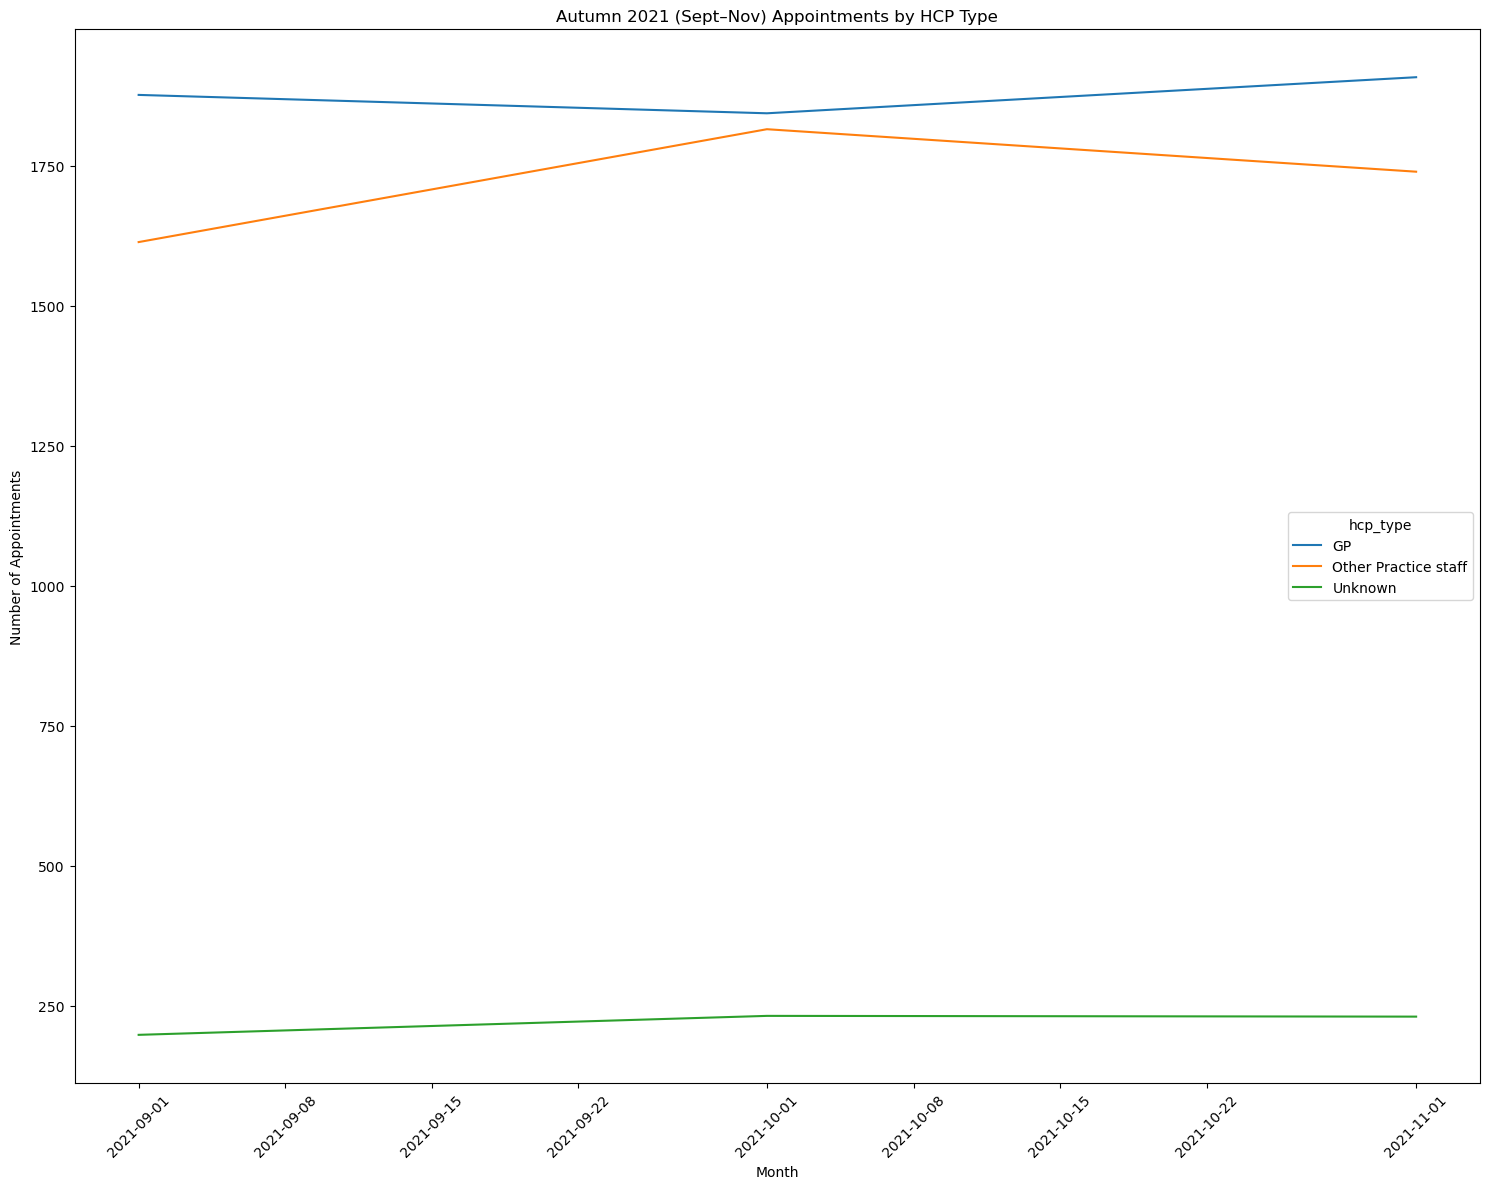

In [16]:
# Convert to datetime
appointments_regional["appointment_month"] = pd.to_datetime(
    appointments_regional["appointment_month"]
)

# Filter for Autumn 2021 (Sept–Nov)
autumn_2021 = appointments_regional[
    (appointments_regional["appointment_month"] >= "2021-09-01") &
    (appointments_regional["appointment_month"] <= "2021-11-30")
]

plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_month",
    y="count_of_appointments",
    hue="hcp_type",   # use hcp_type since service_setting doesn’t exist
    data=autumn_2021,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Autumn 2021 (Sept–Nov) Appointments by HCP Type")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.show()

**Winter (December to February 2022):**

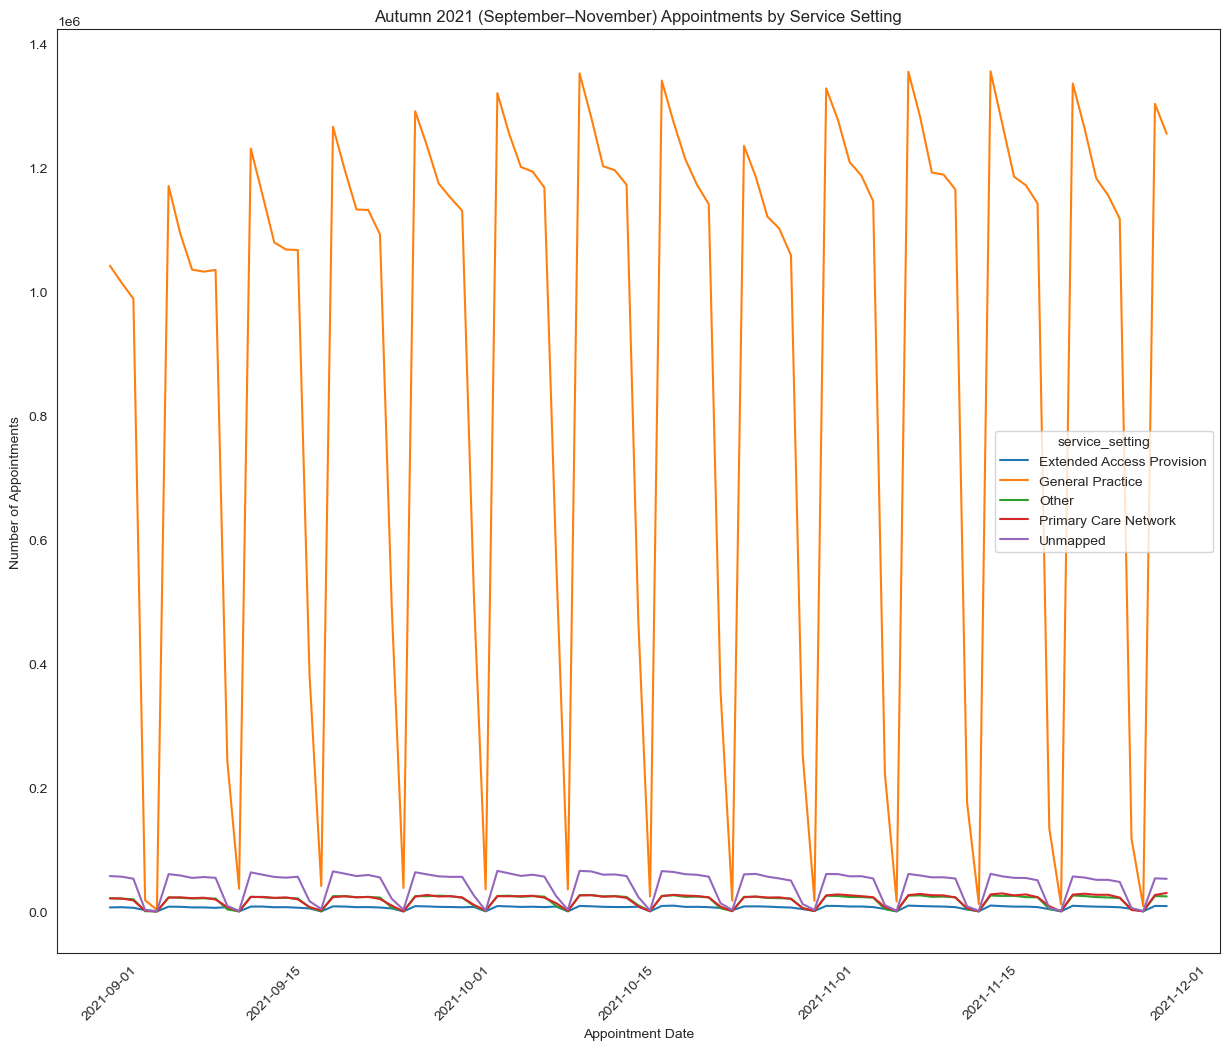

In [8]:
# Look at December to February 2022 in more detail to allow a closer look.
# Create a lineplot.

# Create a separate data set for Autumn 2021
autumn_2021 = nc_ss_day[
    nc_ss_day["appointment_month"].isin(["2021-09", "2021-10", "2021-11"])
]

# View output
autumn_2021.head()

# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_date",
    y="count_of_appointments",
    hue="service_setting",
    data=autumn_2021,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Autumn 2021 (September–November) Appointments by Service Setting")
plt.xlabel("Appointment Date")
plt.ylabel("Number of Appointments")

plt.show()

**Spring (March to May 2022):**

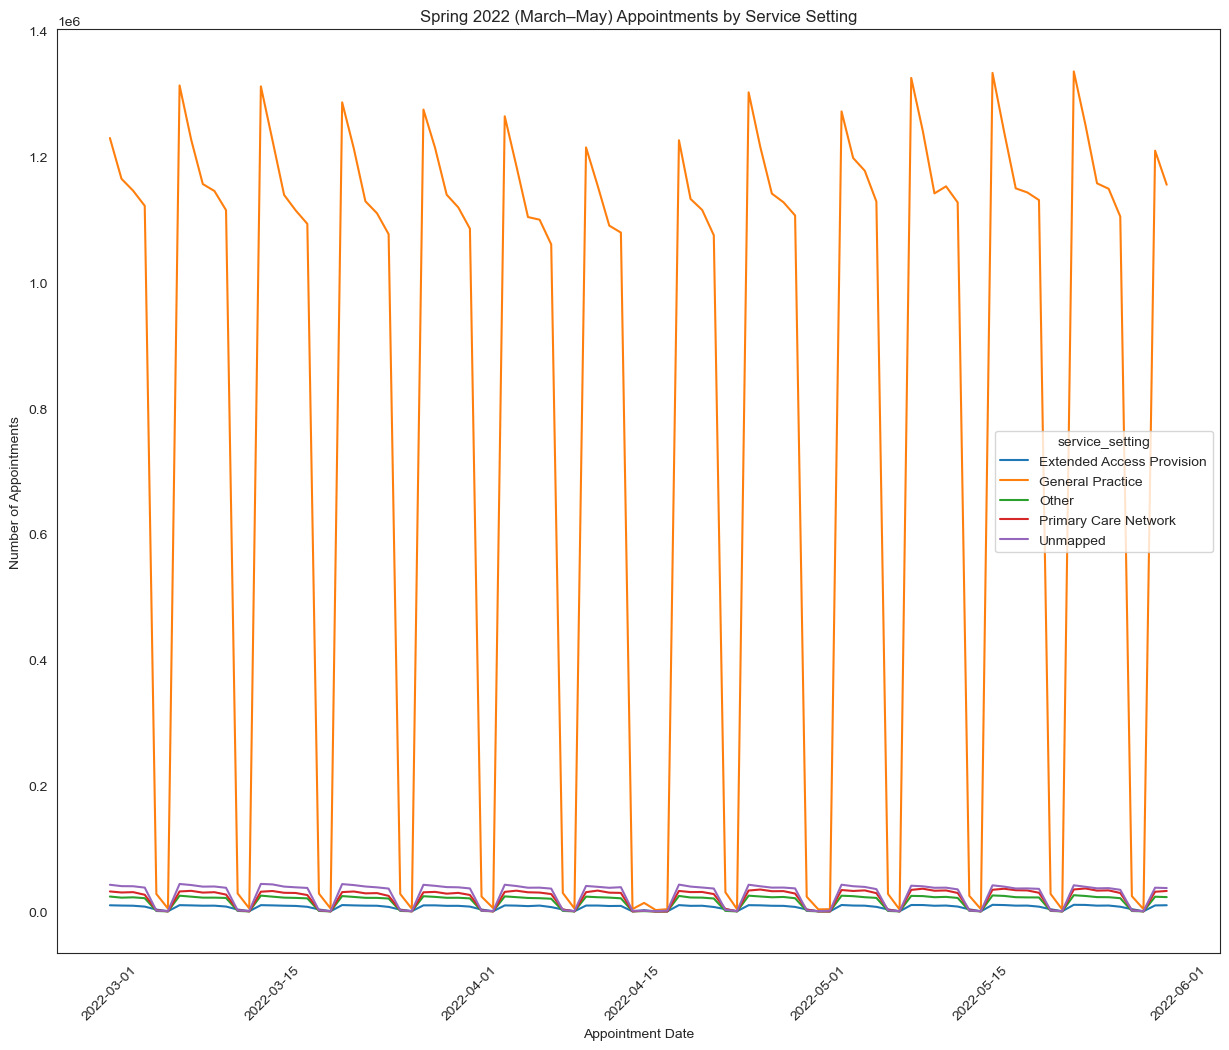

In [10]:
# Look at March to May 2022 in more detail to allow a closer look.
# Create a lineplot.

# Create a separate data set for Spring 2022
spring_2022 = nc_ss_day[
    nc_ss_day["appointment_month"].isin(["2022-03", "2022-04", "2022-05"])
]

# View output
spring_2022.head()

# Look at March to May 2022 in more detail to allow a closer look.
# Create a lineplot.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

sns.lineplot(
    x="appointment_date",
    y="count_of_appointments",
    hue="service_setting",
    data=spring_2022,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Spring 2022 (March–May) Appointments by Service Setting")
plt.xlabel("Appointment Date")
plt.ylabel("Number of Appointments")

plt.show()

# 

# Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [12]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [18]:
# Load the data set.
tweets = pd.read_csv("tweets.csv")

# View the DataFrame.
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [19]:
# Explore the metadata.
# View first five rows
tweets.head()

# View last five rows
tweets.tail()

# Check dataset shape (rows, columns)
tweets.shape

# View column names
tweets.columns

# Check data types and missing values
tweets.info()

# Summary statistics for numerical columns
tweets.describe()

# Include categorical columns in summary
tweets.describe(include='object')

# Check for missing values per column
tweets.isnull().sum()

# Check for duplicate rows
tweets.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


np.int64(0)

In [21]:
# Explore the data set
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [ ]:
# Would it be useful to only look at retweeted and favourite tweet messages?
No 

# Explain your answer.
Would provide a limited view of overall engagement and audience interaction
retweets and favourites indicate popularity and reach, they do not capture the full picture of how users interact with content.

In [26]:
# Create a new DataFrame containing only the text
tweets_text = tweets[["tweet_full_text"]]

# View the DataFrame
tweets_text.head()

,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."


In [27]:
# Loop through the messages, and create a list of values containing the # symbol.
# Create an empty list
tags = []

# Loop through the messages
for message in tweets_text["tweet_full_text"]:
    words = str(message).split()
    for word in words:
        if word.startswith("#"):
            tags.append(word.lower())

# View first 20 extracted hashtags
tags[:20]

['#healthcare',
 '#premisehealth',
 '#hiring',
 '#healthcare',
 '#blogs',
 '#digitaltransformation',
 '#cybersecurity',
 '#accounting',
 '#finance',
 '#healthcare',
 '#firstcoastcna',
 '#cnaexam',
 '#cnaexampreparation',
 '#jacksonville',
 '#cnatraining',
 '#nurse',
 '#nursing',
 '#nurselife',
 '#nursepractitioner',
 '#nurseproblems']

In [29]:
# Convert the series to a DataFrame in preparation for visualisation.
tag_counts = pd.Series(tags).value_counts().reset_index()

# Rename the columns.
tag_counts.columns = ["hashtag", "count"]

# View the DataFrame
tag_counts.head()

,hashtag,count
0,#healthcare,785
1,#health,84
2,#ai,45
3,#medicine,42
4,#job,38


In [31]:
# Convert list to Series and then to DataFrame
tag_counts = pd.Series(tags).value_counts().reset_index()

# Rename the columns
tag_counts.columns = ["hashtag", "count"]

# View the DataFrame
tag_counts.head()

,hashtag,count
0,#healthcare,785
1,#health,84
2,#ai,45
3,#medicine,42
4,#job,38


In [32]:
# Fix the count datatype.
tag_counts["count"] = tag_counts["count"].astype(int)

# View the result.
tag_counts.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   hashtag  1599 non-null   object
 1   count    1599 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 25.1+ KB


In [33]:
# Display records where the count is larger than 10.
tag_counts[tag_counts["count"] > 10]

,hashtag,count
0,#healthcare,785
1,#health,84
2,#ai,45
3,#medicine,42
4,#job,38
5,#medical,35
6,#digitalhealth,30
7,#strategy,30
8,#pharmaceutical,28
9,#medtwitter,27


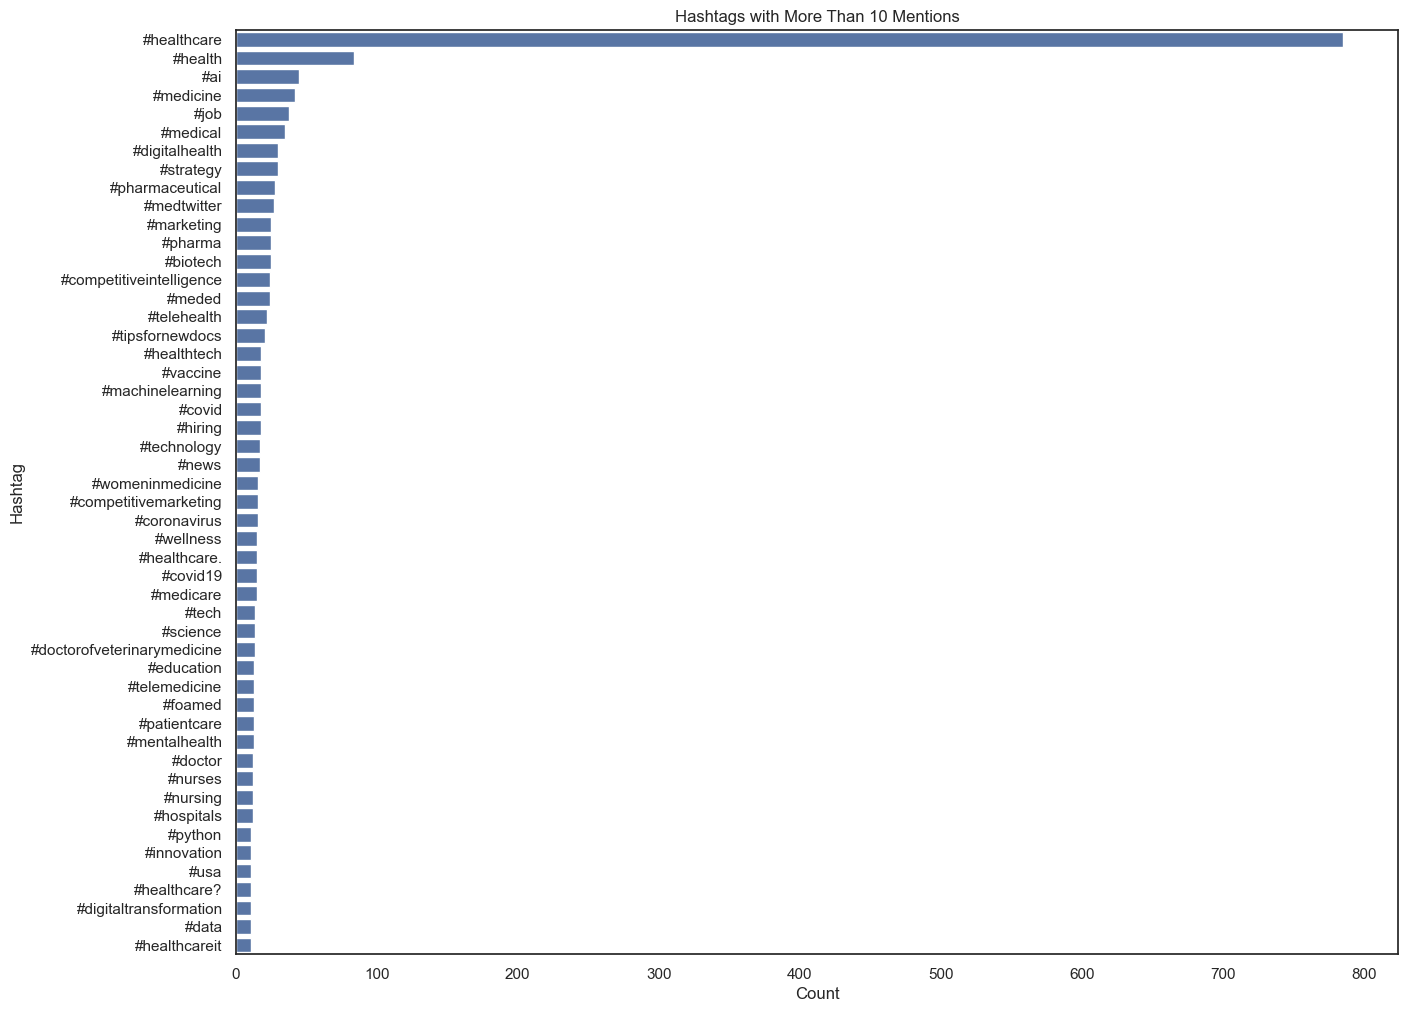

In [34]:
# Create a Seaborn barplot indicating records with a count >10 records.

# Filter data
top_tags = tag_counts[tag_counts["count"] > 10]

# Create figure
plt.figure(figsize=(15, 12))

# Create barplot
sns.barplot(
    data=top_tags,
    x="count",
    y="hashtag"
)

# Add title and labels
plt.title("Hashtags with More Than 10 Mentions")
plt.xlabel("Count")
plt.ylabel("Hashtag")

plt.show()


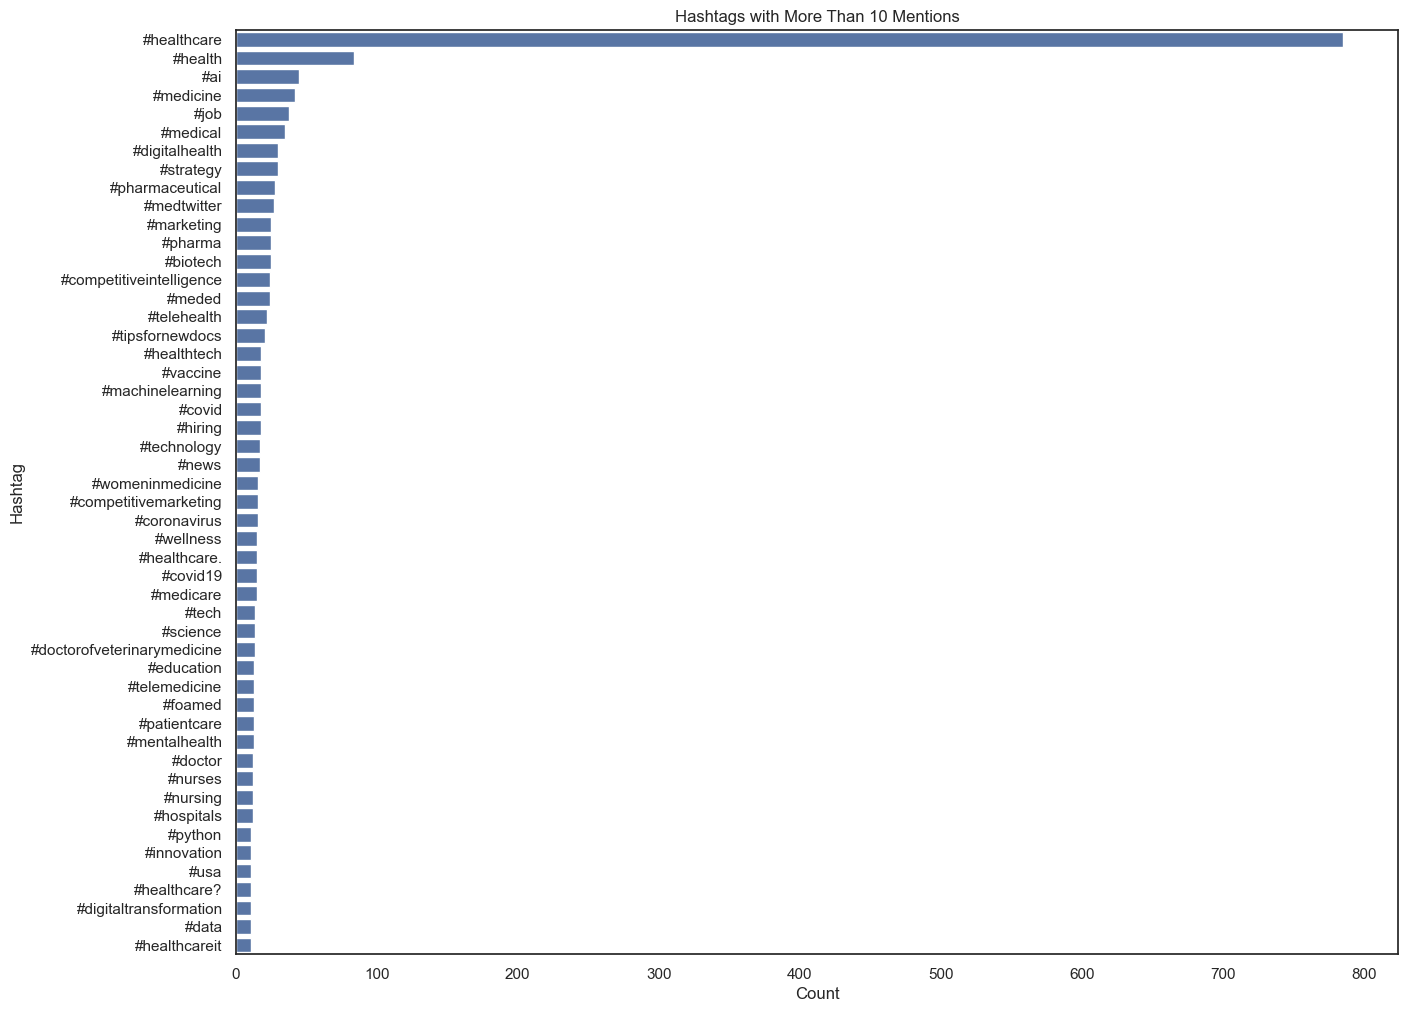

In [36]:

# Filter records with count > 10
top_tags = tag_counts[tag_counts["count"] > 10]

plt.figure(figsize=(15, 12))

sns.barplot(
    data=top_tags,
    x="count",
    y="hashtag"
)

plt.title("Hashtags with More Than 10 Mentions")
plt.xlabel("Count")
plt.ylabel("Hashtag")

# View the barplot.
plt.show()

# 

# Assignment activity 6

### Make recommendations to the NHS. 

In [37]:
# Prepare your workstation.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
sns.set_style("white")

pd.options.display.max_colwidth = 200


# Load the appointments_regional.csv file.
appointments_regional = pd.read_csv("appointments_regional.csv")


# View the DataFrame.
appointments_regional.head()


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


<Figure size 1500x1200 with 0 Axes>

In [39]:
# Print the min and max dates.

# Convert appointment_month to datetime (if not already)
appointments_regional["appointment_month"] = pd.to_datetime(
    appointments_regional["appointment_month"],
    errors="coerce"
)

# Print minimum and maximum dates
print("Minimum date:", appointments_regional["appointment_month"].min())
print("Maximum date:", appointments_regional["appointment_month"].max())

Minimum date: 2020-01-01 00:00:00
Maximum date: 2022-06-01 00:00:00


In [40]:
# Filter the data set to only look at data from 2021-08 onwards.

# Ensure appointment_month is datetime
appointments_regional["appointment_month"] = pd.to_datetime(
    appointments_regional["appointment_month"],
    errors="coerce"
)

# Filter from August 2021 onwards
appointments_regional = appointments_regional[
    appointments_regional["appointment_month"] >= "2021-08-01"
]

# View the filtered DataFrame
appointments_regional.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08-01,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,4961


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [41]:
# Create an aggregated data set to review the different features.

ar_agg = (
    appointments_regional
    .groupby([
        "appointment_month",
        "hcp_type",
        "appointment_status",
        "appointment_mode",
        "time_between_book_and_appointment"
    ])["count_of_appointments"]
    .sum()
    .reset_index()
)

# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08-01,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08-01,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08-01,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08-01,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08-01,GP,Attended,Face-to-Face,8 to 14 Days,398772


In [42]:
# Determine the total number of appointments per month.

ar_df = (
    appointments_regional
    .groupby("appointment_month")["count_of_appointments"]
    .sum()
    .reset_index()
)


# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.

ar_df["utilisation"] = (ar_df["count_of_appointments"] / 30).round(1)


# View the DataFrame.
ar_df.head()

,appointment_month,count_of_appointments,utilisation
0,2021-08-01,23852171,795072.4
1,2021-09-01,28522501,950750.0
2,2021-10-01,30303834,1010127.8
3,2021-11-01,30405070,1013502.3
4,2021-12-01,25140776,838025.9


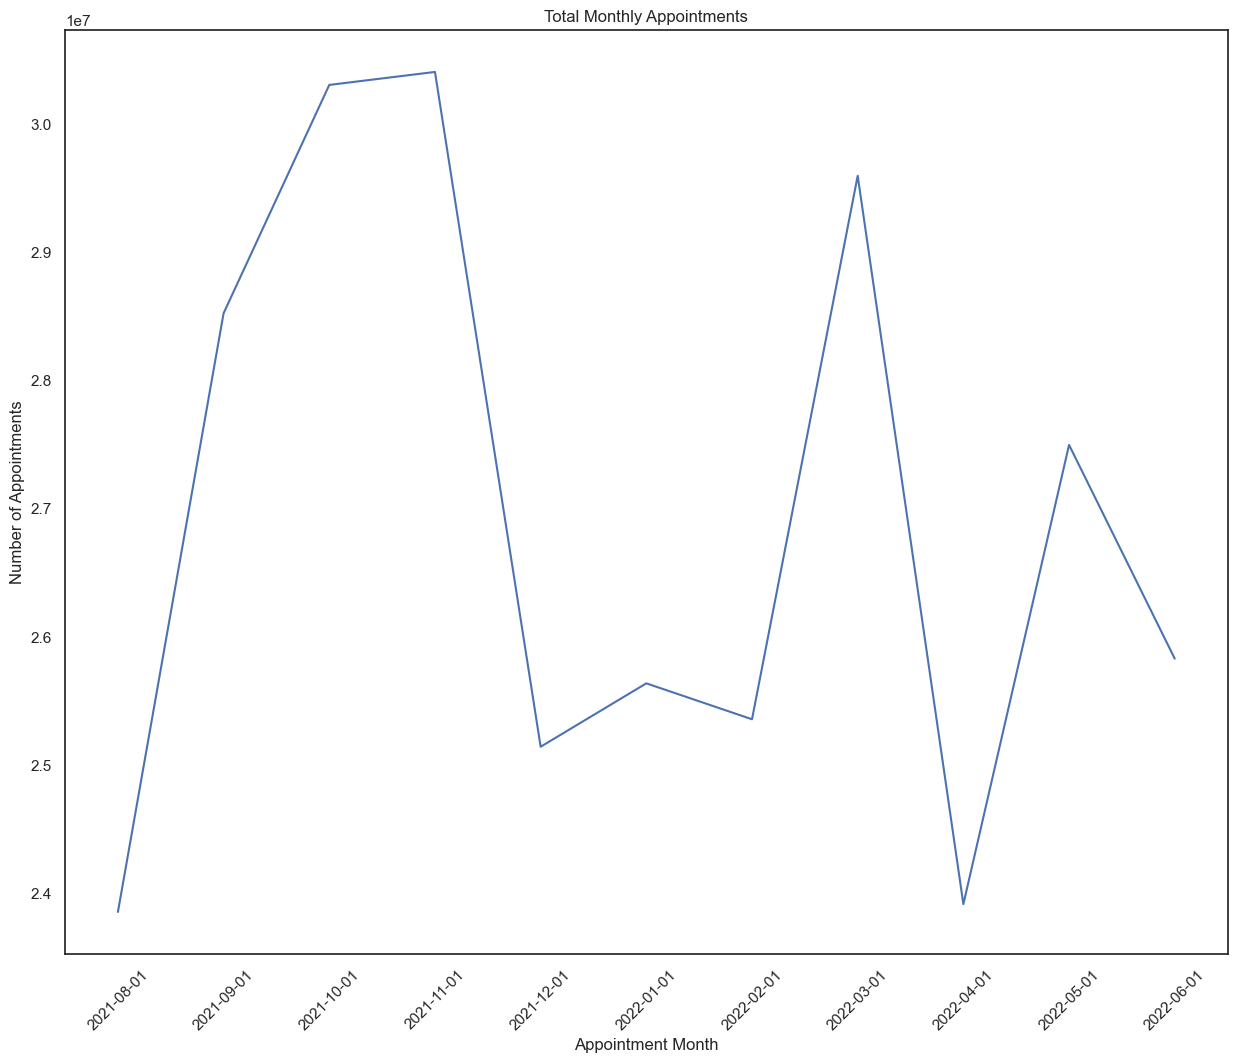

In [43]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.

ar_df["appointment_month"] = ar_df["appointment_month"].astype(str)


# Create a lineplot with Seaborn.

plt.figure(figsize=(15, 12))

sns.lineplot(
    data=ar_df,
    x="appointment_month",
    y="count_of_appointments"
)

plt.xticks(rotation=45)
plt.title("Total Monthly Appointments")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.show()

<Axes: xlabel='appointment_month', ylabel='utilisation'>

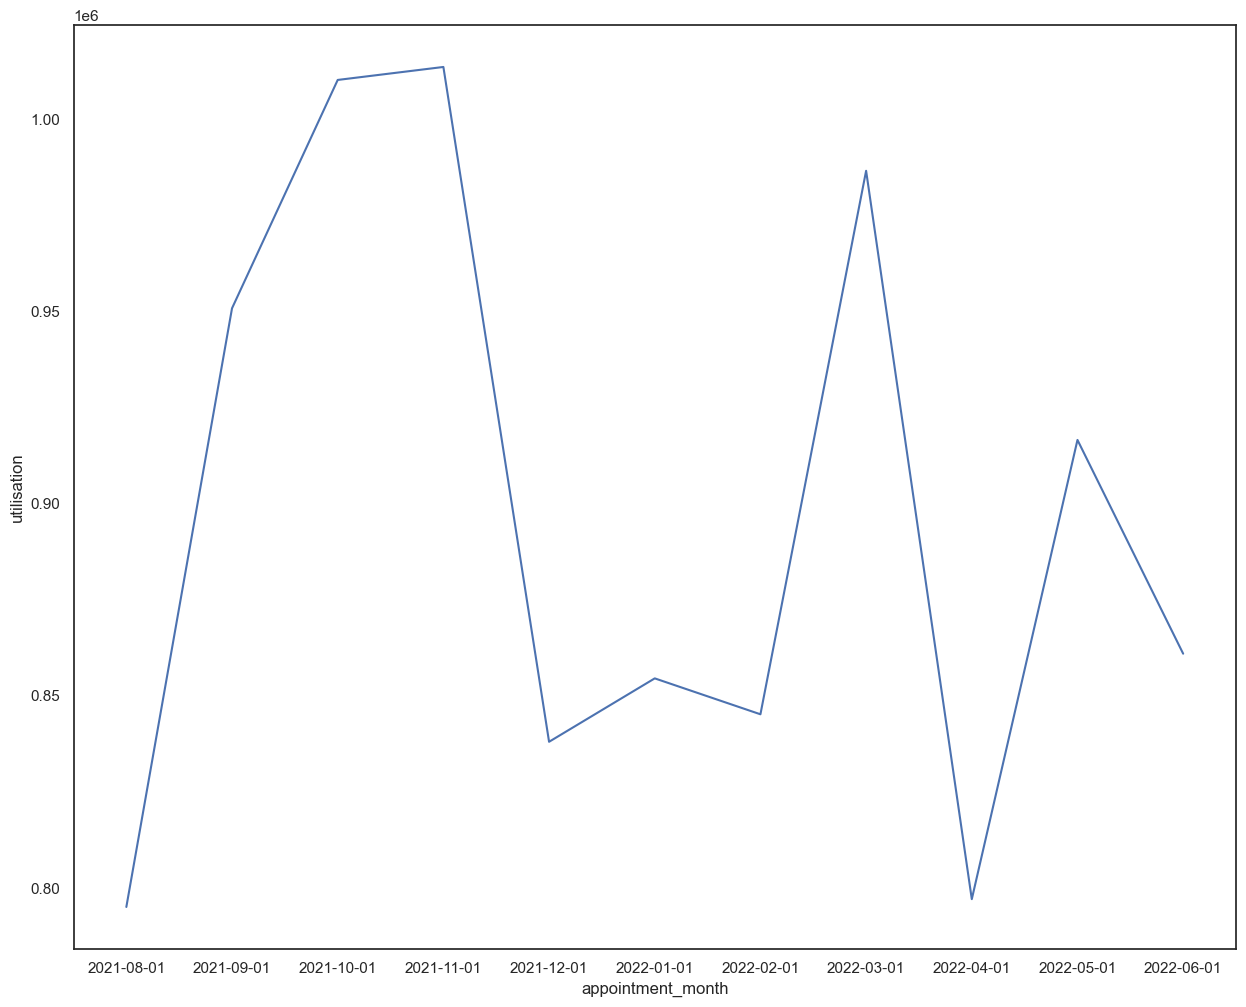

In [44]:
# Plot monthly capacity utilisation.

# Convert appointment_month to string (if not already done)
ar_df["appointment_month"] = ar_df["appointment_month"].astype(str)


# Create a lineplot.

plt.figure(figsize=(15, 12))

sns.lineplot(
    data=ar_df,
    x="appointment_month",
    y="utilisation"
)

**Question 2:** How do the healthcare professional types differ over time?

Text(0.5, 0, 'Appointment Month')

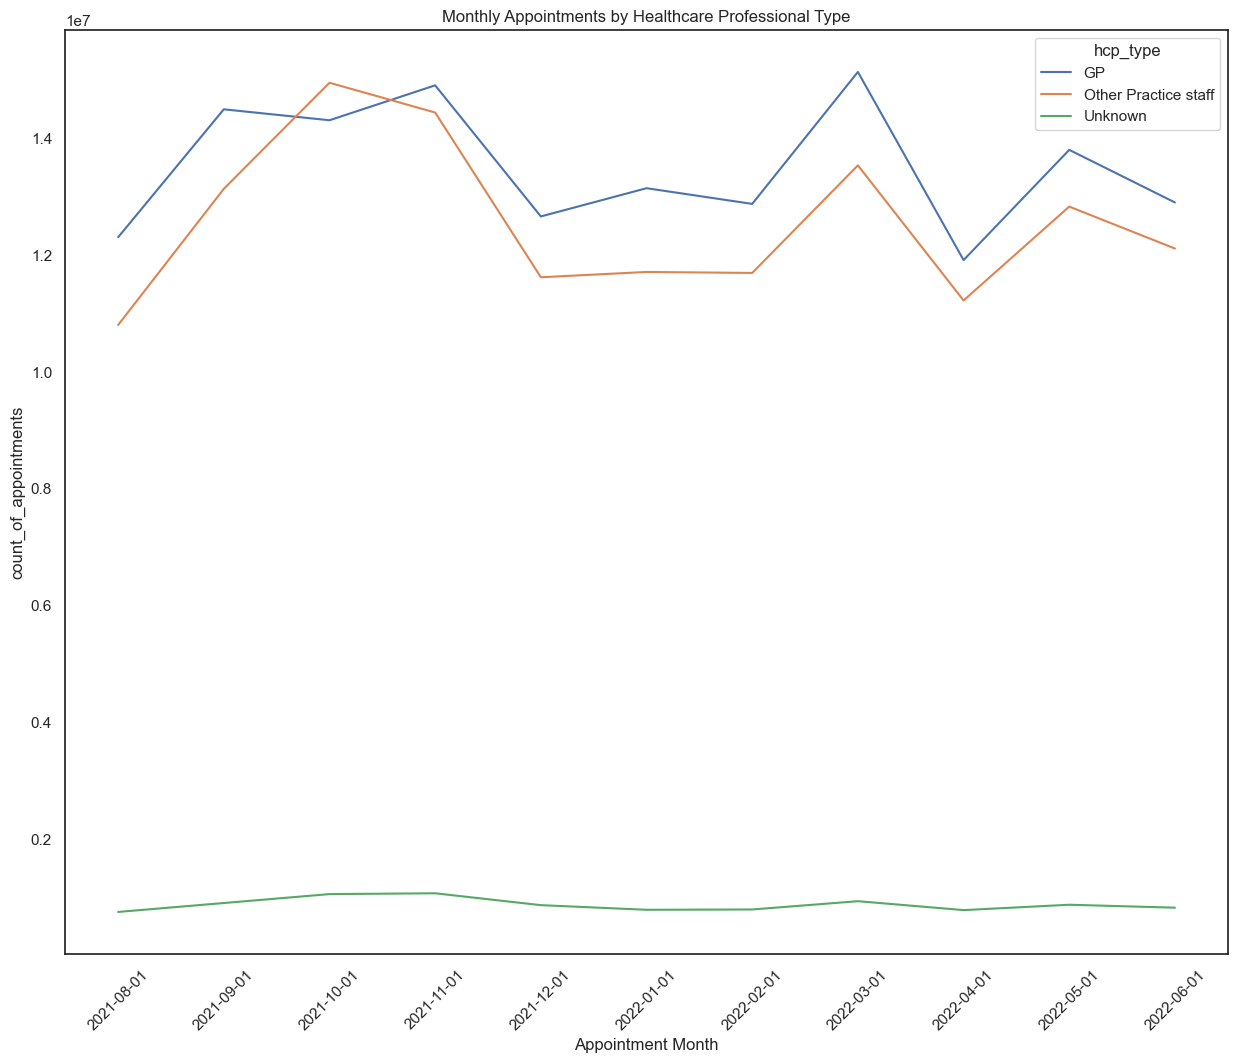

In [46]:
# Create a line plot to answer the question.
# Aggregate appointments by month and healthcare professional type
hcp_trend = (
    appointments_regional
    .groupby(["appointment_month", "hcp_type"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# Convert appointment_month to string for visualisation
hcp_trend["appointment_month"] = hcp_trend["appointment_month"].astype(str)

# Create the line plot
plt.figure(figsize=(15, 12))

sns.lineplot(
    data=hcp_trend,
    x="appointment_month",
    y="count_of_appointments",
    hue="hcp_type"
)

plt.xticks(rotation=45)
plt.title("Monthly Appointments by Healthcare Professional Type")
plt.xlabel("Appointment Month")

**Question 3:** Are there significant changes in whether or not visits are attended?

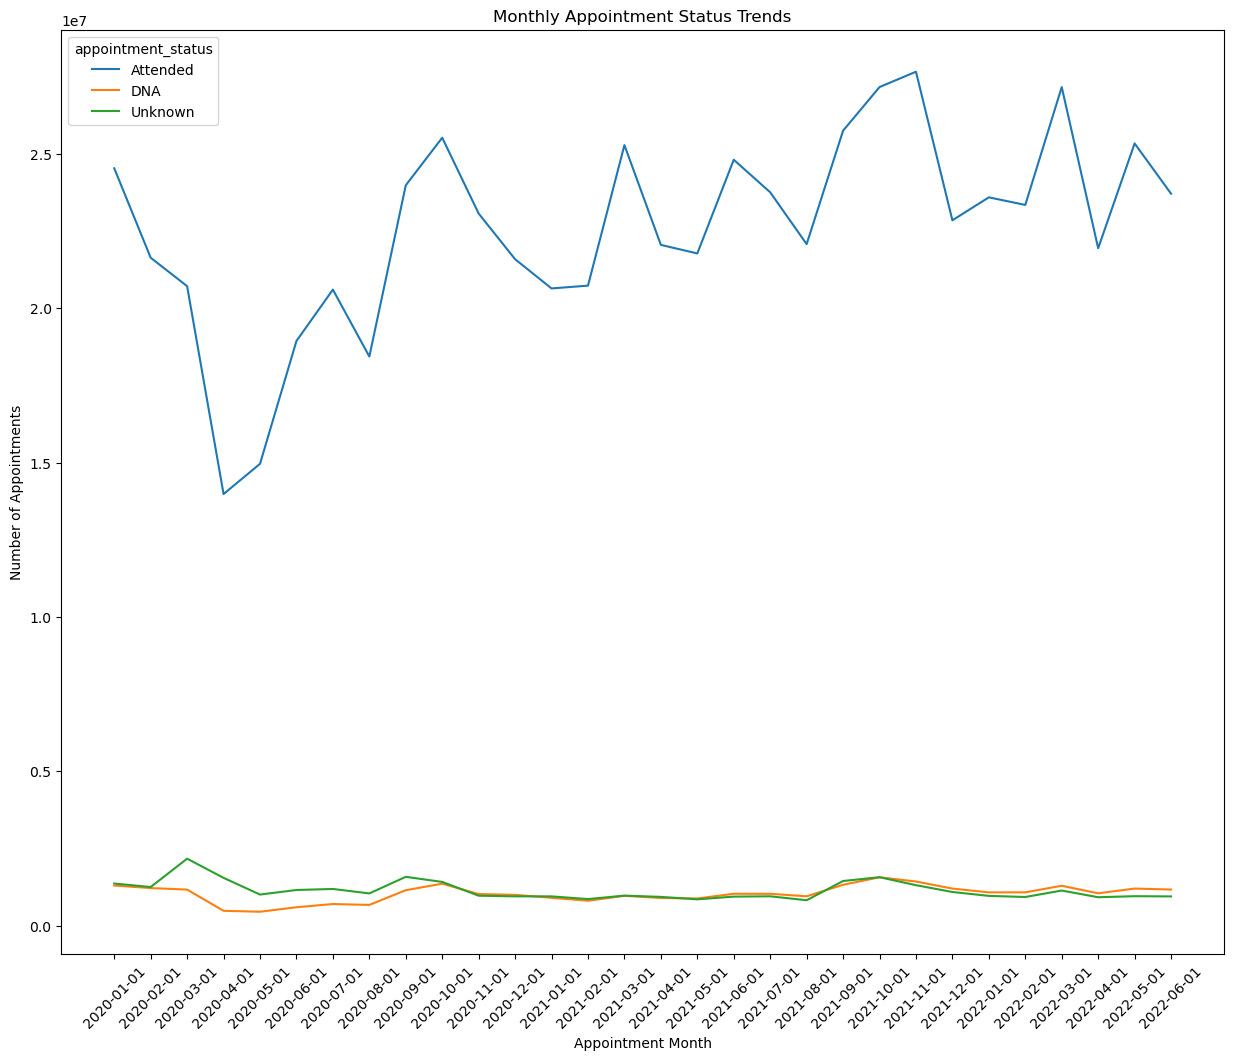

In [5]:
# Create a line plot to answer the question.


# Aggregate by month and appointment status
status_trend = (
    appointments_regional
    .groupby(["appointment_month", "appointment_status"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# Convert appointment_month to string for easier visualisation
status_trend["appointment_month"] = status_trend["appointment_month"].astype(str)

# Create the lineplot
plt.figure(figsize=(15, 12))

sns.lineplot(
    data=status_trend,
    x="appointment_month",
    y="count_of_appointments",
    hue="appointment_status"
)

plt.xticks(rotation=45)
plt.title("Monthly Appointment Status Trends")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.savefig("monthly_appointment_status_trend.png", dpi=300, bbox_inches="tight")
plt.show()

**Question 4:** Are there changes in terms of appointment type and the busiest months?

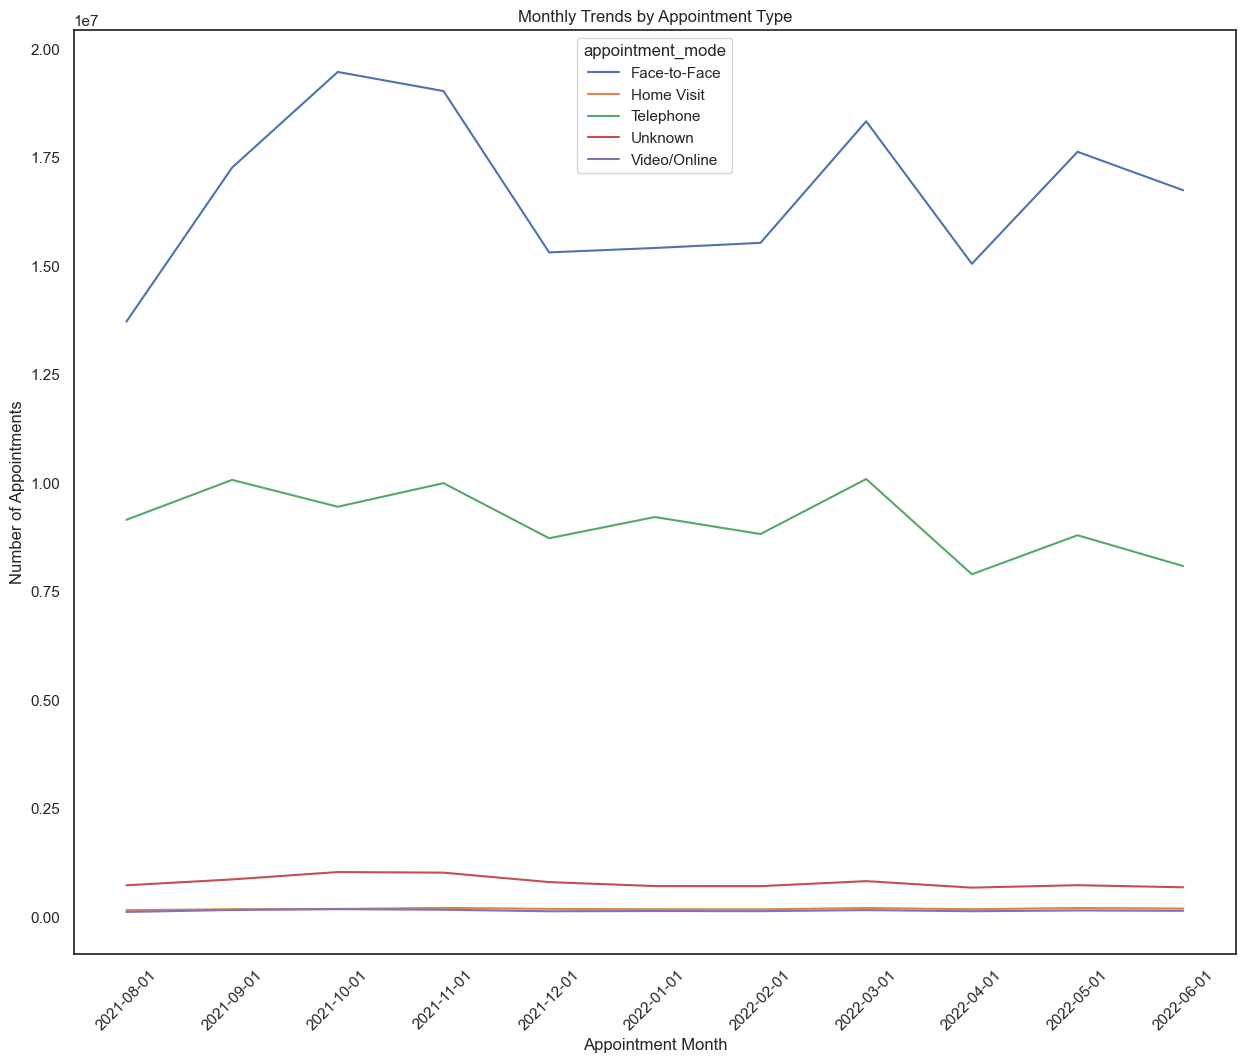

In [48]:
# Create a line plot to answer the question.
# Aggregate by month and appointment mode (type)
mode_trend = (
    appointments_regional
    .groupby(["appointment_month", "appointment_mode"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# Convert appointment_month to string for easier visualisation
mode_trend["appointment_month"] = mode_trend["appointment_month"].astype(str)

# Create the lineplot
plt.figure(figsize=(15, 12))

sns.lineplot(
    data=mode_trend,
    x="appointment_month",
    y="count_of_appointments",
    hue="appointment_mode"
)

plt.xticks(rotation=45)
plt.title("Monthly Trends by Appointment Type")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.show()

**Question 5:** Are there any trends in time between booking and appointment?

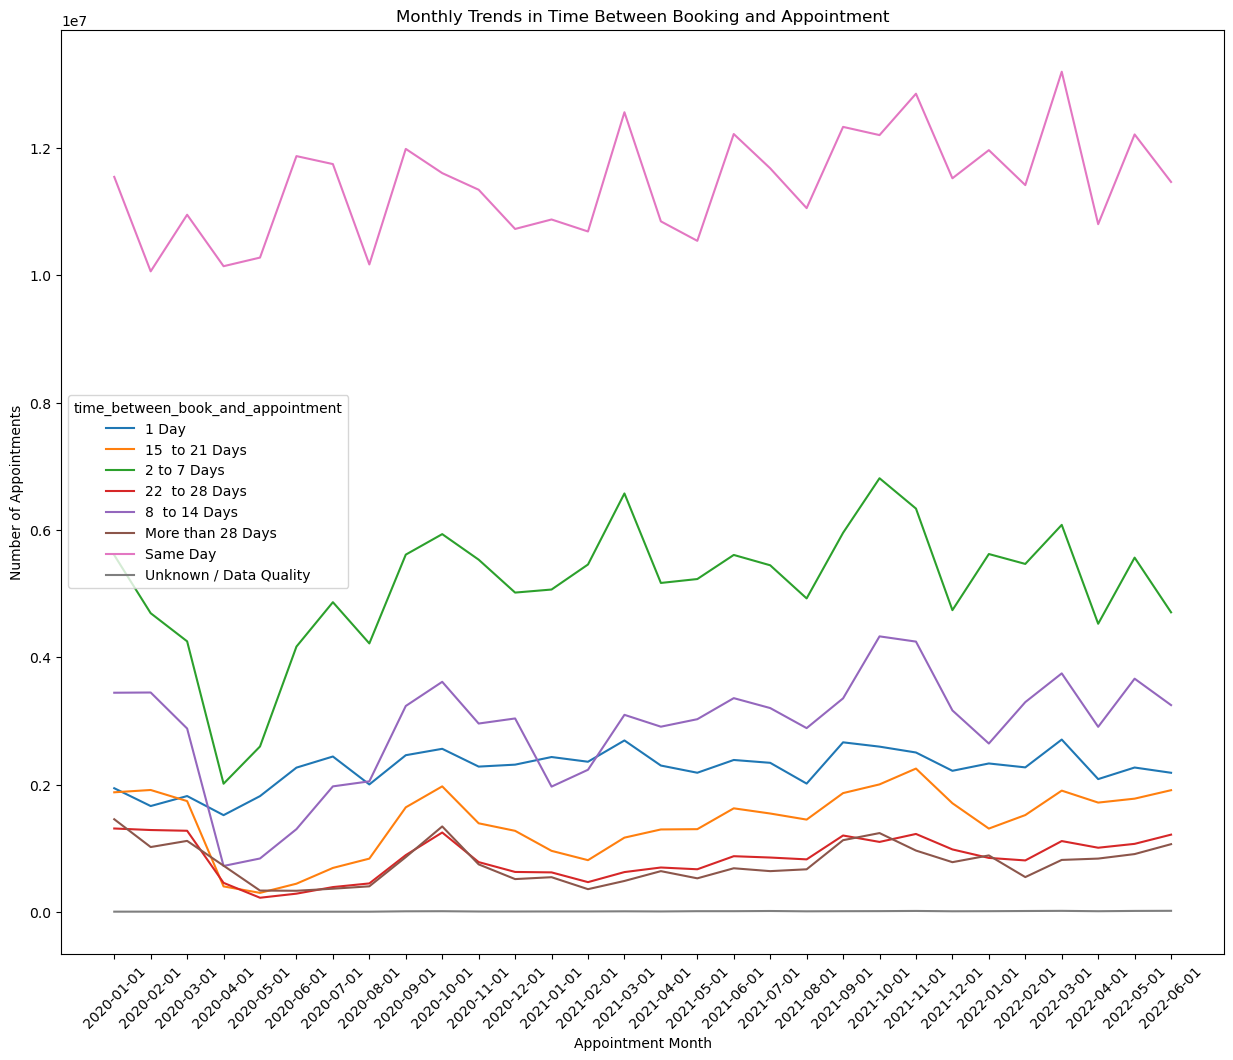

In [2]:
# Create a line plot to answer the question.
# Are there any trends in time between booking and appointment?

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the dataset
appointments_regional = pd.read_csv("appointments_regional.csv")

# Convert appointment_month to datetime
appointments_regional["appointment_month"] = pd.to_datetime(
    appointments_regional["appointment_month"],
    errors="coerce"
)

# Aggregate by month and time between booking and appointment
booking_trend = (
    appointments_regional
    .groupby(["appointment_month", "time_between_book_and_appointment"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# Convert appointment_month to string for visualisation
booking_trend["appointment_month"] = booking_trend["appointment_month"].astype(str)

# Create the lineplot
plt.figure(figsize=(15, 12))

sns.lineplot(
    data=booking_trend,
    x="appointment_month",
    y="count_of_appointments",
    hue="time_between_book_and_appointment"
)

plt.xticks(rotation=45)
plt.title("Monthly Trends in Time Between Booking and Appointment")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")

plt.savefig("booking_trend_lineplot.png", dpi=300, bbox_inches="tight")

plt.show()

**Question 6:** How do the various service settings compare?

In [1]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
import pandas as pd

# Reload the dataset
nc = pd.read_excel("national_categories.xlsx")

# View the DataFrame
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [2]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_monthly = (
    nc
    .groupby("appointment_month")["count_of_appointments"]
    .sum()
    .reset_index()
)

# View the DataFrame.
nc_monthly.head()

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776


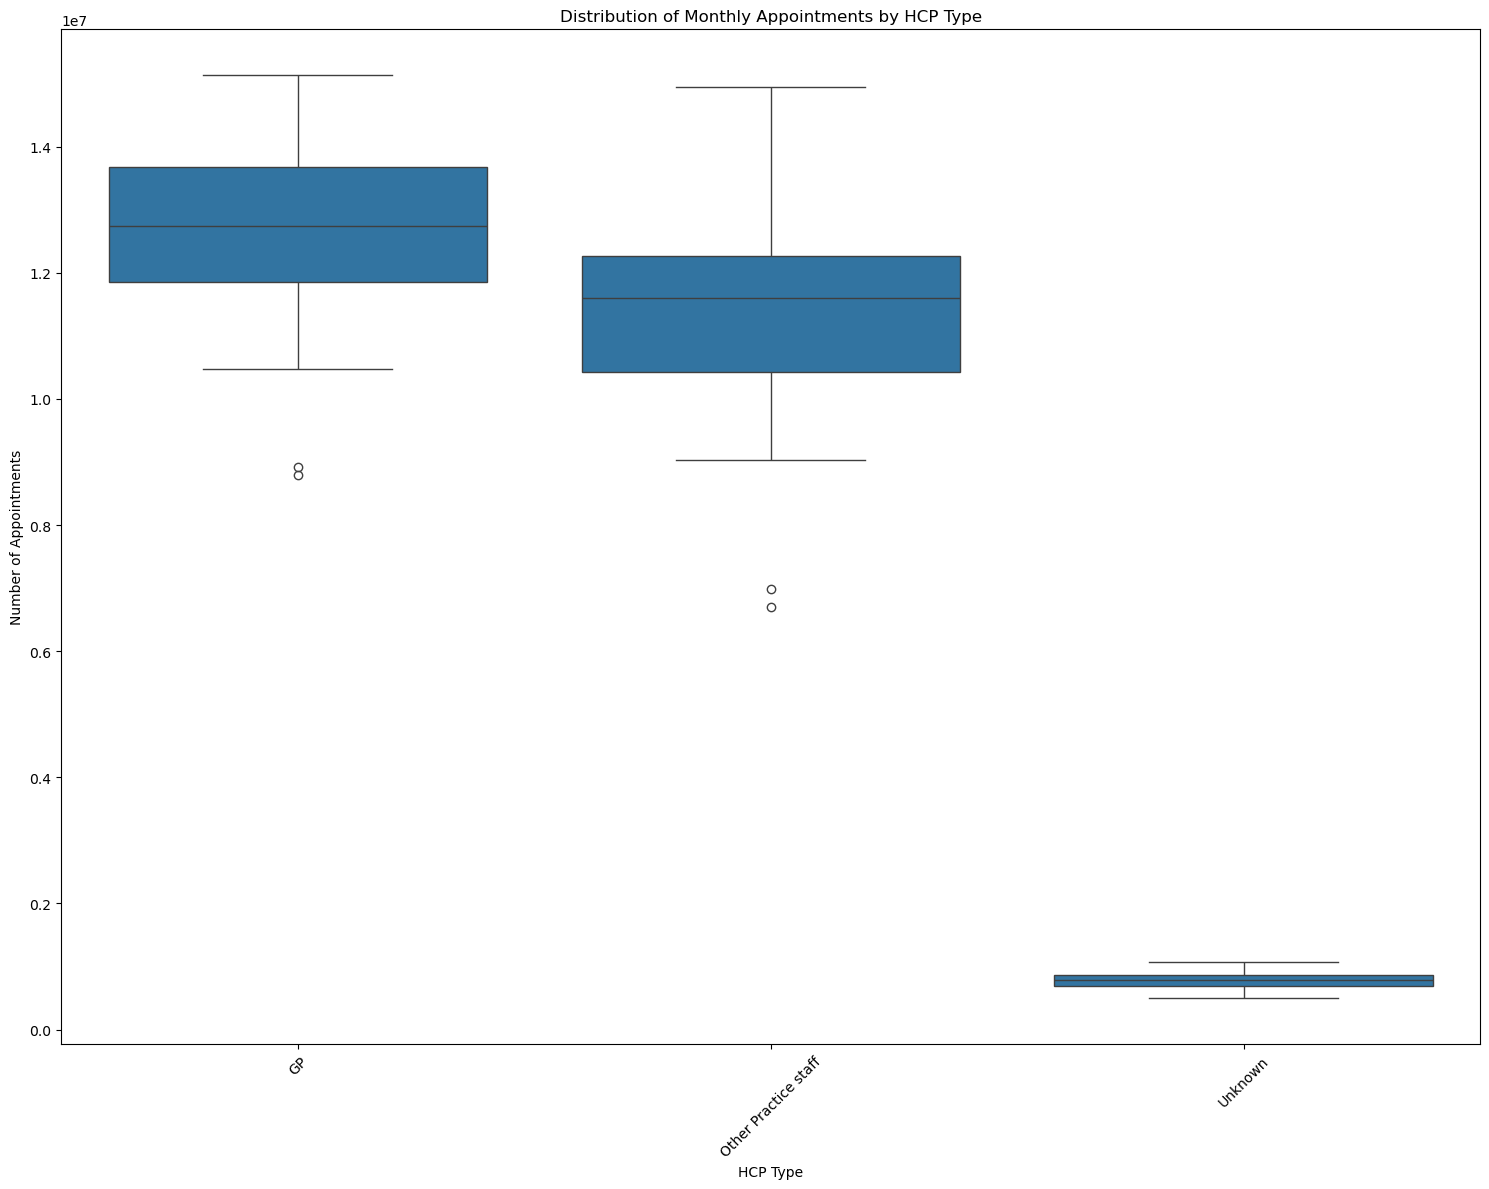

In [12]:
hcp_df = (
    appointments_regional
    .groupby(["appointment_month", "hcp_type"])["count_of_appointments"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 12))

sns.boxplot(
    data=hcp_df,
    x="hcp_type",
    y="count_of_appointments"
)

plt.xticks(rotation=45)
plt.title("Distribution of Monthly Appointments by HCP Type")
plt.xlabel("HCP Type")
plt.ylabel("Number of Appointments")

plt.tight_layout()

plt.savefig("appointment_by_hcg_type.png", dpi=300, bbox_inches="tight")
plt.show()


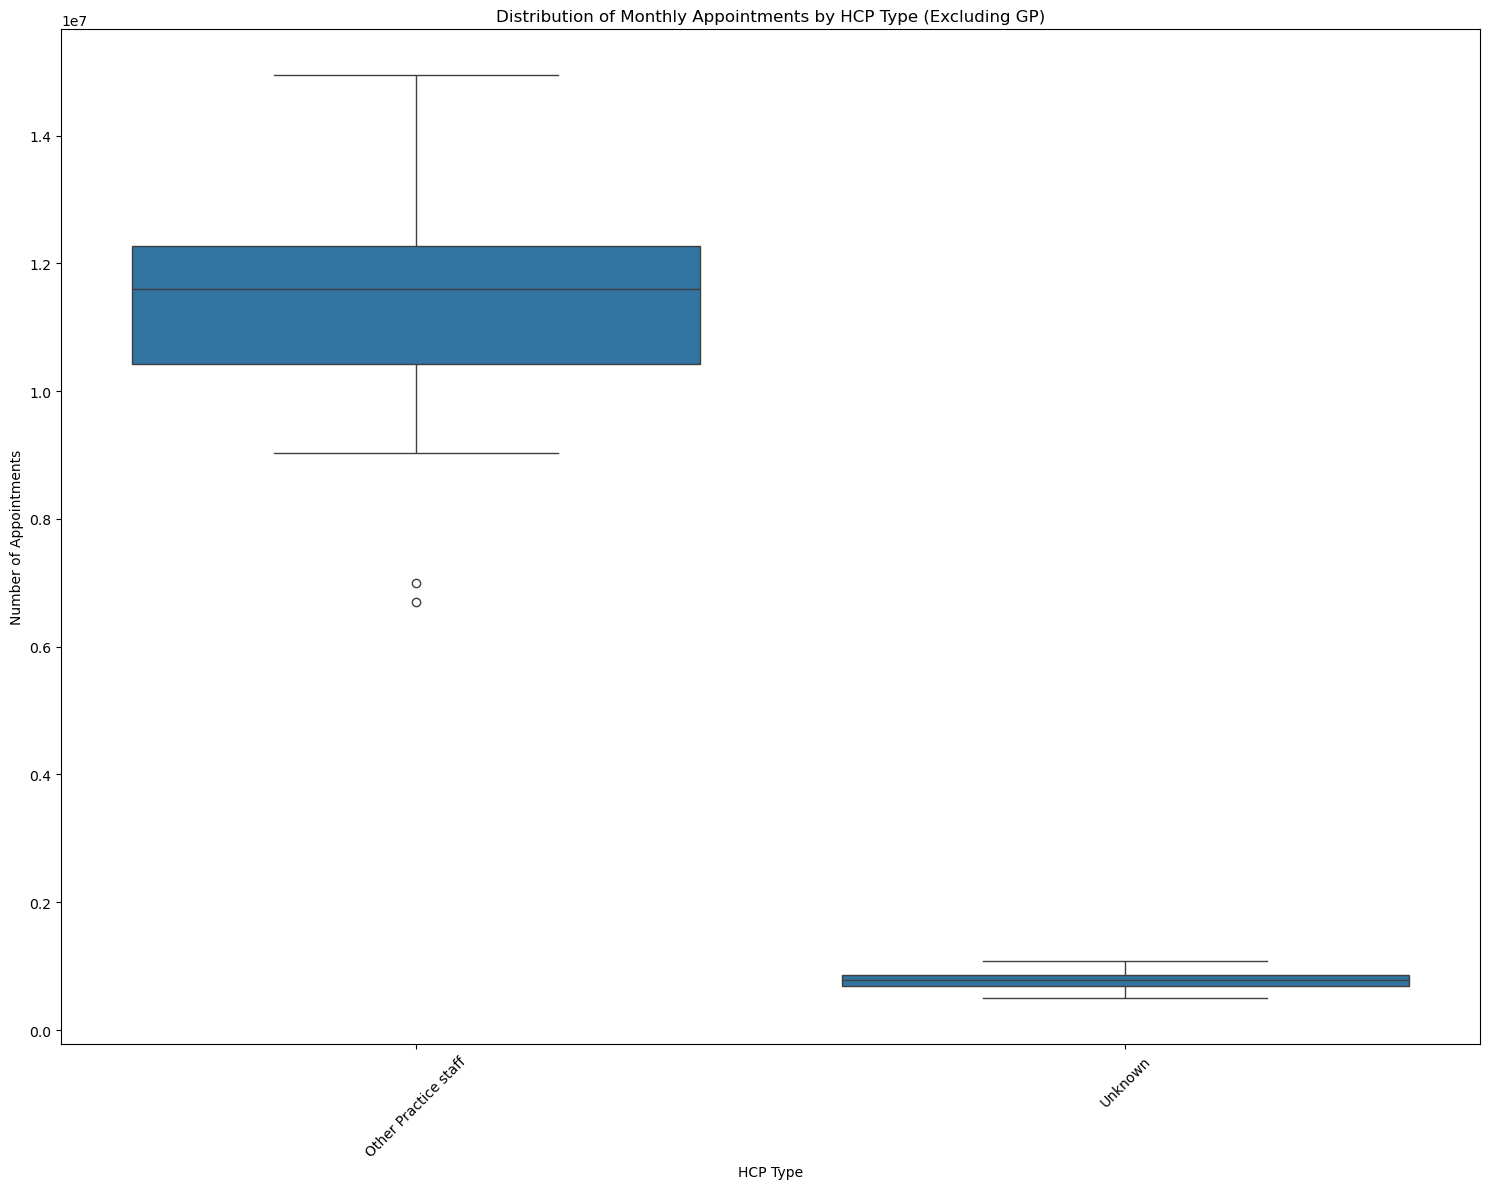

In [15]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
appointments_regional = pd.read_csv("appointments_regional.csv")

# Aggregate monthly appointments by HCP type
hcp_df = (
    appointments_regional
    .groupby(["appointment_month", "hcp_type"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# Exclude GP
hcp_filtered = hcp_df[hcp_df["hcp_type"] != "GP"]

# Create boxplot
plt.figure(figsize=(15, 12))

sns.boxplot(
    data=hcp_filtered,
    x="hcp_type",
    y="count_of_appointments"
)

plt.xticks(rotation=45)
plt.title("Distribution of Monthly Appointments by HCP Type (Excluding GP)")
plt.xlabel("HCP Type")
plt.ylabel("Number of Appointments")

plt.tight_layout()

# Save BEFORE showing
plt.savefig("appointments_by_hcp_type_excluding_gp.png",
            dpi=300,
            bbox_inches="tight")

plt.savefig("appointment_by_hcg_type_excluding_GP.png", dpi=300, bbox_inches="tight")
plt.show()

# 

### Provide a summary of your findings and recommendations based on the analysis.

> Double click to insert your summary.

In [ ]:
There is clear seasonal peaks in demand over October and November
so resources need to be increased over this time including more staff members to cope with demand. 
Seasonal workforce planning during predictable peak months will allow for a shift in current resources rather than further investment. 
There is a high dependency on GP services. Utilisation of non-GP healthcare professionals where clinically appropriate to reduce demand on one service,
increasing usage of the primary care network and extended access provision.
There are persistent but stable missed appointment levels, there is a high but not excessive overall capacity utilisation.
An improvement in the appointment reminder system and targeted communication may reduce DNAs. 
Unmapped appointments need to categorised for more accurate analysis going forward as these account for sufficient data entries– 1054 in August 2021 alone. 
Improve social tracking to proactively detect service pressure, 
potential for hiring social analytic team that can read tweets more in depth to identify recurring issues would be more useful.
Commonly used hashtags provide very limited information.
Further analysis could include predictive modelling of seasonal demand and regression analysis to understand drivers of missed appointments
as current data is limited on specific reasons. 
To conclude, prior to increasing investment the NHS should work to shift current resources, 
seasonal workforce planning to increase staffing during busier months of October and November and utilisation of non-GP healthcare professional services
where clinically appropriate should be implemented. 
Investment, however, should be done in automated appointment reminders as it is possible long wait times are the reason behind missed appointments.
Investment in greater social media analysis would also help identify recurring issues split by demographics such as age and location. 
